## EDA(1/3) BMI Category vs Hypertension 

Due to the incomplete overlap of BMI and Abdominal_Obesity, we should analyze them separately to avoid erroneously excluding valid samples because of an inner join.

In [19]:
# --- BMI Category vs Hypertension (Adults 20+) ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings("ignore")

# Read and merge files
df_demo = pd.read_csv("../data/demo_data/cleaned_demographics_data.csv")
df_bp = pd.read_csv("../data/combined_blood_pressure_data.csv")
df_bmi = pd.read_csv("../data/examination_data/cleaned_BMI_examination_data.csv")

df_bmi_merge = df_demo.merge(df_bp, on="Participant_ID").merge(df_bmi, on="Participant_ID")

# Keep rows for adults 20+, those with hypertension, BMI classification, and weight.
df_bmi_filtered = df_bmi_merge[
    (df_bmi_merge['Age_Years'] >= 20) &
    df_bmi_merge['Hypertensive'].notna() &
    df_bmi_merge['BMI_Category'].notna() &
    (df_bmi_merge['Exam_Weight'] > 0)
]
# According to the latest data and estimates from the U.S. Census Bureau, as of 2024, the estimated population of people aged 20 and over in the United States is around 258 million.

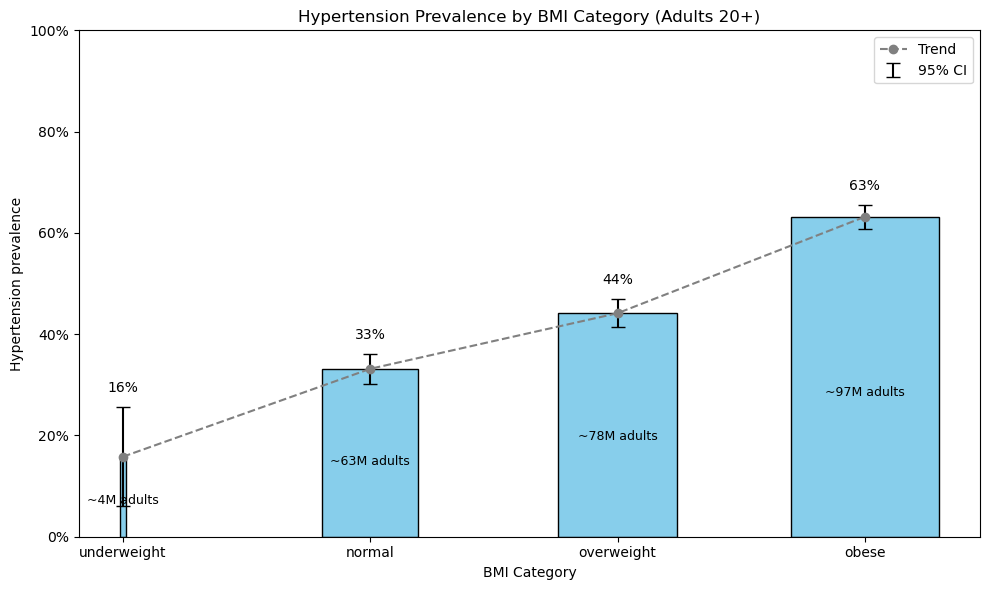

In [20]:
# Calculate weighted prevalence
def compute_weighted_ci(group):
    weights = group['Exam_Weight']
    p = np.average(group['Hypertensive'], weights=weights)
    weight_sum = weights.sum()
    weight_sq_sum = (weights**2).sum()
    n_eff = (weight_sum ** 2) / weight_sq_sum
    se = np.sqrt(p * (1 - p) / n_eff)
    ci_lower = max(0, p - 1.96 * se)
    ci_upper = min(1, p + 1.96 * se)
    return pd.Series({
        'Weighted_Hypertension_Prevalence': p,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        # 'Sample_Size': len(group),
        'Weighted_Population': weight_sum
    })

bmi_results = df_bmi_filtered.groupby("BMI_Category").apply(compute_weighted_ci).reset_index()

# --- revise order for BMI category ---
bmi_order = ['underweight', 'normal', 'overweight', 'obese']
bmi_results['BMI_Category'] = pd.Categorical(bmi_results['BMI_Category'], categories=bmi_order, ordered=True)
bmi_results = bmi_results.sort_values('BMI_Category').reset_index(drop=True)

# --- Bar width represents US adult population ---
bmi_results['Norm_Pop'] = bmi_results['Weighted_Population'] / bmi_results['Weighted_Population'].max() #  let the audience to feel the difference between the largest group and other groups.
 # More intuitively reflect the proportional differences (who is particularly large, and who is particularly small)


# --- visulization ---
plt.figure(figsize=(10, 6))
bar_positions = np.arange(len(bmi_results))

bars = plt.bar(
    bar_positions,
    bmi_results['Weighted_Hypertension_Prevalence'],
    width=bmi_results['Norm_Pop'] * 0.6,
    color='skyblue',
    edgecolor='black'
)

# add error bar 
plt.errorbar(
    x=bar_positions,
    y=bmi_results['Weighted_Hypertension_Prevalence'],
    yerr=[
        bmi_results['Weighted_Hypertension_Prevalence'] - bmi_results['CI_Lower'],
        bmi_results['CI_Upper'] - bmi_results['Weighted_Hypertension_Prevalence']
    ],
    fmt='none', ecolor='black', capsize=5, label="95% CI"
)

# labeling
for i, row in bmi_results.iterrows():
    percent = int(round(row['Weighted_Hypertension_Prevalence'] * 100))
    pop_m = int(round(row['Weighted_Population'] / 1_000_000))
    
    # label population size 
    plt.text(i, row['Weighted_Hypertension_Prevalence'] * 0.45,
             f"~{pop_m}M adults", ha='center', va='center', fontsize=9)
    
    # hypertension rate on top of bars
    plt.text(i, row['CI_Upper'] + 0.03,
             f"{percent}%", ha='center', fontsize=10)

# add trendline
plt.plot(bar_positions, bmi_results['Weighted_Hypertension_Prevalence'],
         marker='o', linestyle='--', color='gray', label='Trend')

# set up 
plt.xticks(bar_positions, bmi_results['BMI_Category'])
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.title("Hypertension Prevalence by BMI Category (Adults 20+)")
plt.xlabel("BMI Category")
plt.ylabel("Hypertension prevalence")
plt.ylim(0, 1)

# remove gridlines
plt.grid(False)
plt.legend()
plt.tight_layout()

# save pic
plt.savefig("../visualization/hypertension_by_BMI_category_US_adults.png", dpi=300, bbox_inches='tight')

plt.show()
    # Bar heights represent hypertension prevalence.
    # Bar widths represent normalized population proportions.

# --- Save output for Tableau ---
bmi_results.to_csv("../output/hypertension_by_BMI_category_US_adults.csv", index=False)


# Internet research below: 
According to the latest data from CDC and other health institutions, the United States is facing a severe obesity and overweight issue. Tens of millions, or even over a hundred million, adults are classified as obese or overweight, posing a significant challenge to public health. 

Key data: 
Overweight population: Data indicates that around 99 million American adults fall into the overweight category.

Obesity population: Based on data from 2017 to March 2020, over 100 million American adults suffer from obesity.


## EDA(2/3) Abdominal Obesity vs Hypertension 

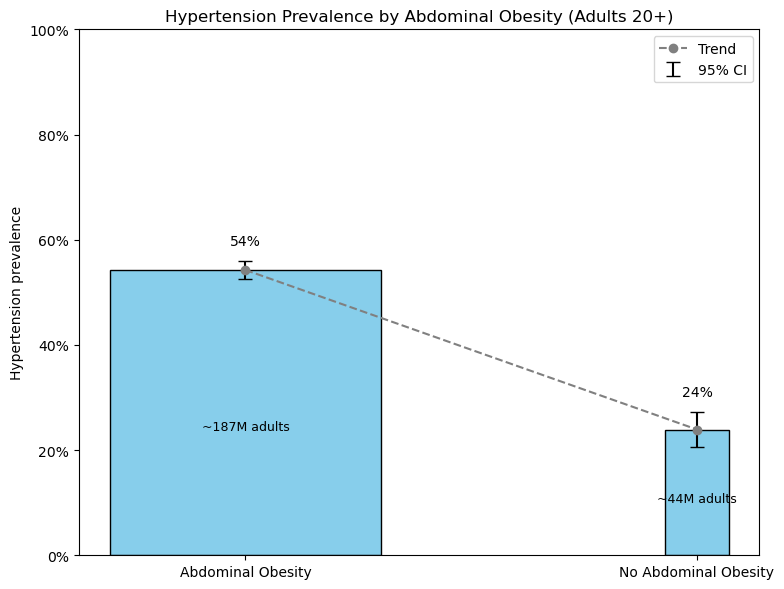

In [22]:
# --- Abdominal Obesity vs Hypertension (Adults 20+) ---

# merge df_demo, df_bp, df_bmi to get data on abdominal obesity 
df_abdo_merge = df_demo.merge(df_bp, on="Participant_ID").merge(df_bmi, on="Participant_ID")


# Filter: adults 20+, valid hypertension + exam weight, and abdominal obesity
df_abd_filtered = df_abdo_merge[
    (df_abdo_merge['Age_Years'] >= 20) &
    df_abdo_merge['Hypertensive'].notna() &
    df_abdo_merge['Abdominal_Obesity'].notna() &
    (df_abdo_merge['Exam_Weight'] > 0)
]

# Function to calculate weighted prevalence + CI
def compute_weighted_ci(group):
    weights = group['Exam_Weight']
    p = np.average(group['Hypertensive'], weights=weights)
    weight_sum = weights.sum()
    weight_sq_sum = (weights**2).sum()
    n_eff = (weight_sum ** 2) / weight_sq_sum
    se = np.sqrt(p * (1 - p) / n_eff)
    ci_lower = max(0, p - 1.96 * se)
    ci_upper = min(1, p + 1.96 * se)
    return pd.Series({
        'Weighted_Hypertension_Prevalence': p,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'Weighted_Population': weight_sum
    })

# Group + label mapping
abd_results = df_abd_filtered.groupby("Abdominal_Obesity").apply(compute_weighted_ci).reset_index()
abd_results['Group_Label'] = abd_results['Abdominal_Obesity'].map({True: "Abdominal Obesity", False: "No Abdominal Obesity"})
abd_results = abd_results.sort_values("Group_Label").reset_index(drop=True)
abd_results['Norm_Pop'] = abd_results['Weighted_Population'] / abd_results['Weighted_Population'].max()

# --- Visualization ---
plt.figure(figsize=(8, 6))
bar_positions = np.arange(len(abd_results))

bars = plt.bar(
    bar_positions,
    abd_results['Weighted_Hypertension_Prevalence'],
    width=abd_results['Norm_Pop'] * 0.6,
    color='skyblue',
    edgecolor='black'
)

# Error bars
plt.errorbar(
    x=bar_positions,
    y=abd_results['Weighted_Hypertension_Prevalence'],
    yerr=[
        abd_results['Weighted_Hypertension_Prevalence'] - abd_results['CI_Lower'],
        abd_results['CI_Upper'] - abd_results['Weighted_Hypertension_Prevalence']
    ],
    fmt='none', ecolor='black', capsize=5, label="95% CI"
)

# Labels
for i, row in abd_results.iterrows():
    percent = int(round(row['Weighted_Hypertension_Prevalence'] * 100))
    pop_m = int(round(row['Weighted_Population'] / 1_000_000))
    
    plt.text(i, row['Weighted_Hypertension_Prevalence'] * 0.45,
             f"~{pop_m}M adults", ha='center', va='center', fontsize=9)
    plt.text(i, row['CI_Upper'] + 0.03,
             f"{percent}%", ha='center', fontsize=10)

# Trend line
plt.plot(bar_positions, abd_results['Weighted_Hypertension_Prevalence'],
         marker='o', linestyle='--', color='gray', label='Trend')

# Setup
plt.xticks(bar_positions, abd_results['Group_Label'])
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.title("Hypertension Prevalence by Abdominal Obesity (Adults 20+)")
# plt.xlabel("Abdominal Obesity Status")
plt.ylabel("Hypertension prevalence")
plt.ylim(0, 1)
plt.grid(False)
plt.legend()
plt.tight_layout()

# Save
plt.savefig("../visualization/hypertension_by_abdominal_obesity_US_adults.png", dpi=300, bbox_inches='tight')
abd_results.to_csv("../output/hypertension_by_abdominal_obesity_US_adults.csv", index=False)
plt.show()


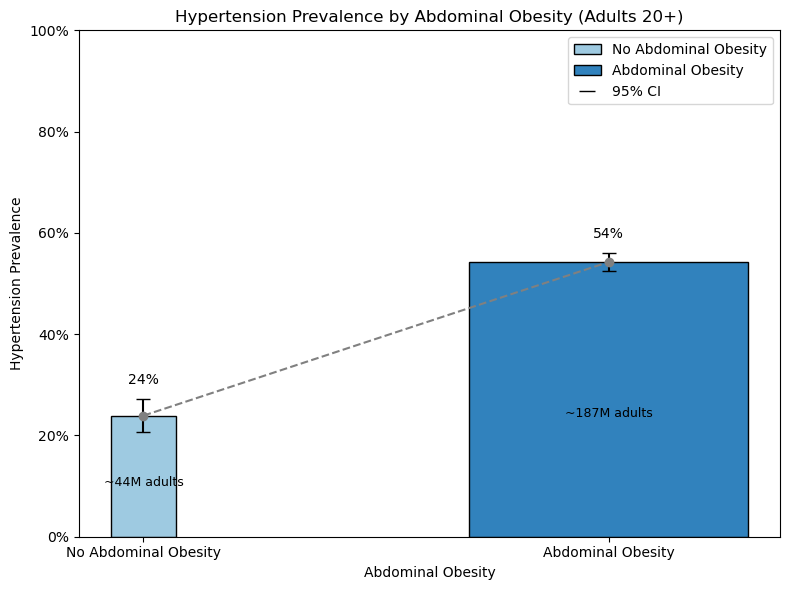

In [38]:
# --- Abdominal Obesity vs Hypertension (Adults 20+) ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore")

# --- Step 1: Load and merge data ---
df_demo = pd.read_csv("../data/demo_data/cleaned_demographics_data.csv")
df_bp = pd.read_csv("../data/combined_blood_pressure_data.csv")
df_bmi = pd.read_csv("../data/examination_data/cleaned_BMI_examination_data.csv")

df_merge = df_demo.merge(df_bp, on="Participant_ID").merge(df_bmi, on="Participant_ID")

# --- Step 2: Filter valid adult cases (20+) with non-missing values ---
df_filtered = df_merge[
    (df_merge["Age_Years"] >= 20) &
    df_merge["Hypertensive"].notna() &
    df_merge["Abdominal_Obesity"].notna() &
    (df_merge["Exam_Weight"] > 0)
]

# --- Step 3: Weighted hypertension prevalence & 95% CI ---
def compute_weighted_ci(group):
    weights = group['Exam_Weight']
    p = np.average(group['Hypertensive'], weights=weights)
    weight_sum = weights.sum()
    weight_sq_sum = (weights**2).sum()
    n_eff = (weight_sum ** 2) / weight_sq_sum
    se = np.sqrt(p * (1 - p) / n_eff)
    ci_lower = max(0, p - 1.96 * se)
    ci_upper = min(1, p + 1.96 * se)
    return pd.Series({
        'Weighted_Hypertension_Prevalence': p,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'Weighted_Population': weight_sum
    })

abd_results = df_filtered.groupby("Abdominal_Obesity").apply(compute_weighted_ci).reset_index()
abd_results['Label'] = abd_results['Abdominal_Obesity'].map({True: "Abdominal Obesity", False: "No Abdominal Obesity"})

# --- Step 4: Normalize width for visual scaling ---
abd_results['Norm_Pop'] = abd_results['Weighted_Population'] / abd_results['Weighted_Population'].max()

# --- Step 5: Plot ---
plt.figure(figsize=(8, 6))
bar_positions = np.arange(len(abd_results))

# Custom colors
colors = ['#9ecae1', '#3182bd']
bars = plt.bar(
    bar_positions,
    abd_results['Weighted_Hypertension_Prevalence'],
    width=abd_results['Norm_Pop'] * 0.6,
    color=colors,
    edgecolor='black'
)

# Error bars
plt.errorbar(
    x=bar_positions,
    y=abd_results['Weighted_Hypertension_Prevalence'],
    yerr=[
        abd_results['Weighted_Hypertension_Prevalence'] - abd_results['CI_Lower'],
        abd_results['CI_Upper'] - abd_results['Weighted_Hypertension_Prevalence']
    ],
    fmt='none', ecolor='black', capsize=5, label="95% CI"
)

# Labels
for i, row in abd_results.iterrows():
    percent = int(round(row['Weighted_Hypertension_Prevalence'] * 100))
    pop_m = int(round(row['Weighted_Population'] / 1_000_000))

    plt.text(i, row['Weighted_Hypertension_Prevalence'] * 0.45,
             f"~{pop_m}M adults", ha='center', va='center', fontsize=9)
    plt.text(i, row['CI_Upper'] + 0.03,
             f"{percent}%", ha='center', fontsize=10)
    
# Trend line
plt.plot(bar_positions, abd_results['Weighted_Hypertension_Prevalence'],
         marker='o', linestyle='--', color='gray', label='Trend')

# Setup
plt.xticks(bar_positions, abd_results['Label'])
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.title("Hypertension Prevalence by Abdominal Obesity (Adults 20+)")
plt.ylabel("Hypertension Prevalence")
plt.xlabel("Abdominal Obesity")
plt.ylim(0, 1)
plt.grid(False)

# Legend
legend_handles = [
    Patch(facecolor=colors[0], edgecolor='black', label="No Abdominal Obesity"),
    Patch(facecolor=colors[1], edgecolor='black', label="Abdominal Obesity"),
    plt.Line2D([0], [0], color='black', linestyle='none', marker='_', markersize=12, label='95% CI')
]
plt.legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
plt.savefig("../visualization/hypertension_by_abdominal_obesity_US_adults.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Step 6: Export table for Tableau ---
abd_results.to_csv("../output/hypertension_by_abdominal_obesity_US_adults.csv", index=False)


## EDA(3/3) BMI + Abdominal Obesity vs Hypertension 


In [23]:
# --- BMI + Abdominal Obesity vs Hypertension (Adults 20+) ---
df_merge = df_demo.merge(df_bp, on="Participant_ID").merge(df_bmi, on="Participant_ID")

# Filter: adults with complete data
df_filtered = df_merge[
    (df_merge['Age_Years'] >= 20) &
    df_merge['Hypertensive'].notna() &
    df_merge['BMI_Category'].notna() &
    df_merge['Abdominal_Obesity'].notna() &
    (df_merge['Exam_Weight'] > 0)
].copy()

# Get value counts of BMI categories & Abdominal obesity (incl. NaN)
bmi_counts = df_filtered['BMI_Category'].value_counts(dropna=False)
abdominal_counts = df_filtered['Abdominal_Obesity'].value_counts(dropna=False)

# print outputs 
print("BMI_Category value counts:")
print(bmi_counts)

print("\n" + "-"*40 + "\n")
print("Abdominal_Obesity value counts::")
print(abdominal_counts)

BMI_Category value counts:
BMI_Category
obese          2311
overweight     1839
normal         1451
underweight      75
Name: count, dtype: int64

----------------------------------------

Abdominal_Obesity value counts::
Abdominal_Obesity
True     4725
False     951
Name: count, dtype: int64


In [25]:
# 看看 AbOb+ 的性别分布是否严重偏向女性
df_filtered[df_filtered['Abdominal_Obesity'] == True]['Gender_x'].value_counts()


Gender_x
male      2427
female    2298
Name: count, dtype: int64

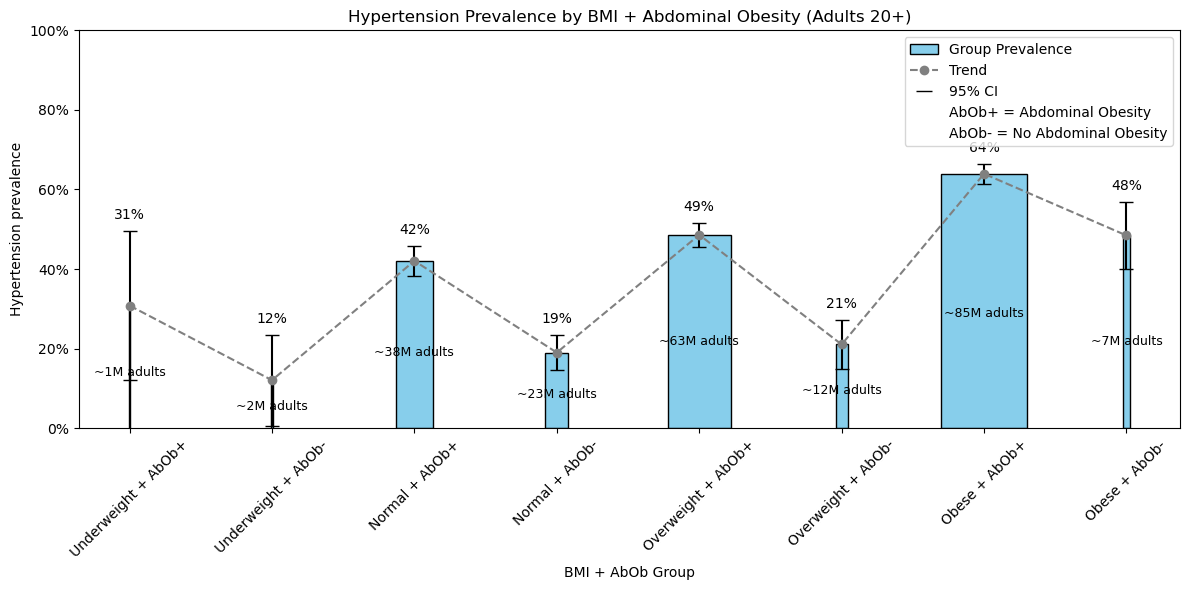

In [29]:
# capitalize BMI category for better visualization in the graph 
df_filtered['BMI_Category'] = df_filtered['BMI_Category'].str.capitalize()

# Create combined group
df_filtered['BMI_Ab_Group'] = df_filtered['BMI_Category'].astype(str) + ' + ' + df_filtered['Abdominal_Obesity'].map({True: 'AbOb+', False: 'AbOb-'})

# Function to calculate weighted prevalence and CI
def compute_weighted_ci(group):
    weights = group['Exam_Weight']
    p = np.average(group['Hypertensive'], weights=weights)
    weight_sum = weights.sum()
    weight_sq_sum = (weights**2).sum()
    n_eff = (weight_sum ** 2) / weight_sq_sum
    se = np.sqrt(p * (1 - p) / n_eff)
    ci_lower = max(0, p - 1.96 * se)
    ci_upper = min(1, p + 1.96 * se)
    return pd.Series({
        'Weighted_Hypertension_Prevalence': p,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'Weighted_Population': weight_sum
    })

combo_results = df_filtered.groupby("BMI_Ab_Group").apply(compute_weighted_ci).reset_index()

# Sort group order by BMI then AbOb+ first
group_order = sorted(combo_results['BMI_Ab_Group'].unique(), key=lambda x: (
    ['Underweight', 'Normal', 'Overweight', 'Obese'].index(x.split(' + ')[0]),
        # x = "Normal + AbOb+", then x.split(' + ')[0] would be "Normal".
        # ['Underweight', 'Normal', 'Overweight', 'Obese'].index(...): "Normal" would correspond to index 1, "Overweight" would correspond to index 2
        # This ensures that the groups are sorted in the order of Underweight, Normal, Overweight, and then Obese.
    0 if 'AbOb+' in x else 1
        # 0 if 'AbOb+' in x else 1: This checks if the string 'AbOb+' is present in x
        # This ensures that groups containing 'AbOb+' are prioritized (appear earlier) within the same BMI category. -> Abdominal obesity True appears first 
))
combo_results['BMI_Ab_Group'] = pd.Categorical(combo_results['BMI_Ab_Group'], categories=group_order, ordered=True)
combo_results = combo_results.sort_values("BMI_Ab_Group").reset_index(drop=True)

# Normalize population for width
combo_results['Norm_Pop'] = combo_results['Weighted_Population'] / combo_results['Weighted_Population'].max()

# --- Visualization ---
plt.figure(figsize=(12, 6))
bar_positions = np.arange(len(combo_results))

bars = plt.bar(
    bar_positions,
    combo_results['Weighted_Hypertension_Prevalence'],
    width=combo_results['Norm_Pop'] * 0.6,
    color='skyblue',
    edgecolor='black'
)

# Error bars
plt.errorbar(
    x=bar_positions,
    y=combo_results['Weighted_Hypertension_Prevalence'],
    yerr=[
        combo_results['Weighted_Hypertension_Prevalence'] - combo_results['CI_Lower'],
        combo_results['CI_Upper'] - combo_results['Weighted_Hypertension_Prevalence']
    ],
    fmt='none', ecolor='black', capsize=5, label="95% CI"
)

# Labels
for i, row in combo_results.iterrows():
    percent = int(round(row['Weighted_Hypertension_Prevalence'] * 100))
    pop_m = int(round(row['Weighted_Population'] / 1_000_000))
    
    plt.text(i, row['Weighted_Hypertension_Prevalence'] * 0.45,
             f"~{pop_m}M adults", ha='center', va='center', fontsize=9)
    plt.text(i, row['CI_Upper'] + 0.03,
             f"{percent}%", ha='center', fontsize=10)

# Trend line
plt.plot(bar_positions, combo_results['Weighted_Hypertension_Prevalence'],
         marker='o', linestyle='--', color='gray', label='Trend')

# Axis setup
plt.xticks(bar_positions, combo_results['BMI_Ab_Group'], rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.title("Hypertension Prevalence by BMI + Abdominal Obesity (Adults 20+)")
plt.xlabel("BMI + AbOb Group")
plt.ylabel("Hypertension prevalence")
plt.ylim(0, 1)
plt.grid(False)

# Custom legend
from matplotlib.patches import Patch
custom_legend = [
    Patch(facecolor='skyblue', edgecolor='black', label='Group Prevalence'),
    plt.Line2D([0], [0], color='gray', linestyle='--', marker='o', label='Trend'),
    plt.Line2D([0], [0], color='black', linestyle='none', marker='_', markersize=12, label='95% CI'),
    Patch(color='white', label='AbOb+ = Abdominal Obesity'),
    Patch(color='white', label='AbOb- = No Abdominal Obesity')
]
plt.legend(handles=custom_legend, loc='upper right')

plt.tight_layout()

# Save
plt.savefig("../visualization/hypertension_by_BMI_PLUS_abdominal_obesity_US_adults.png", dpi=300, bbox_inches='tight')
combo_results.to_csv("../output/hypertension_by_BMI_PLUS_abdominal_obesity_US_adults.csv", index=False)

plt.show()


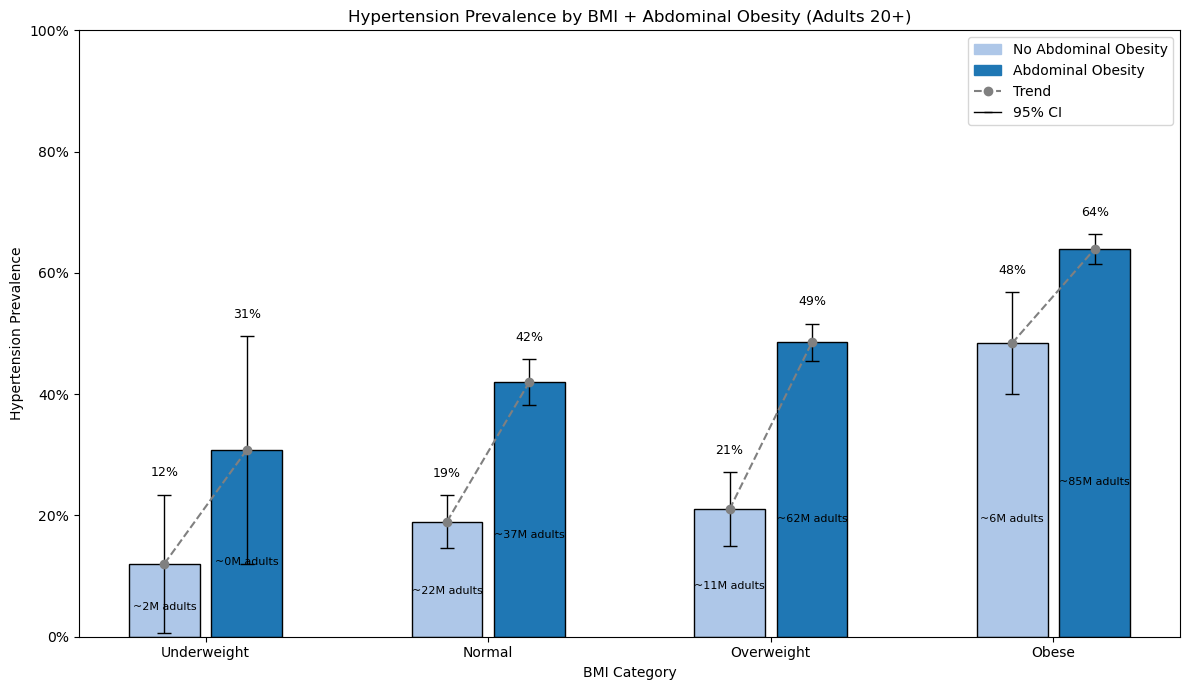

In [39]:
# --- Visualization: BMI + Abdominal Obesity vs Hypertension (Adults 20+) ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Load the results CSV (already includes computed prevalence + CI)
df = pd.read_csv("../output/hypertension_by_BMI_PLUS_abdominal_obesity_US_adults.csv")

# Split BMI and AbOb into separate columns
df[['BMI_Category', 'AbOb_Status']] = df['BMI_Ab_Group'].str.split(' \+ ', expand=True)

# Reorder for grouped bars
bmi_order = ['Underweight', 'Normal', 'Overweight', 'Obese']
abob_order = ['AbOb-', 'AbOb+']

df['BMI_Category'] = pd.Categorical(df['BMI_Category'], categories=bmi_order, ordered=True)
df['AbOb_Status'] = pd.Categorical(df['AbOb_Status'], categories=abob_order, ordered=True)
df = df.sort_values(['BMI_Category', 'AbOb_Status']).reset_index(drop=True)

# Set bar width scaling
df['Norm_Pop'] = df['Weighted_Population'] / df['Weighted_Population'].max()

# Set positions for grouped bars
group_count = len(bmi_order)
bar_width = 0.35
group_spacing = 1.2
positions = []
current = 0

for _ in range(group_count):
    positions.extend([current, current + bar_width])
    current += group_spacing

df['x_pos'] = positions

# Create plot
plt.figure(figsize=(12, 7))
colors = {
    'AbOb+': '#1f77b4',  # deep blue
    'AbOb-': '#aec7e8'   # light blue
}

# Draw bars
for i, row in df.iterrows():
    plt.bar(
        row['x_pos'],
        row['Weighted_Hypertension_Prevalence'],
        width=0.3,
        color=colors[row['AbOb_Status']],
        edgecolor='black'
    )
    # error bar
    plt.errorbar(
        row['x_pos'],
        row['Weighted_Hypertension_Prevalence'],
        yerr=[[row['Weighted_Hypertension_Prevalence'] - row['CI_Lower']],
              [row['CI_Upper'] - row['Weighted_Hypertension_Prevalence']]],
        fmt='none',
        ecolor='black',
        capsize=5,
        linewidth=1
    )
    # label on top
    plt.text(row['x_pos'], row['CI_Upper'] + 0.03,
             f"{row['Weighted_Hypertension_Prevalence'] * 100:.0f}%",
             ha='center', fontsize=9)
    # population label
    plt.text(row['x_pos'], row['Weighted_Hypertension_Prevalence'] * 0.4,
             f"~{int(row['Weighted_Population']/1e6)}M adults",
             ha='center', fontsize=8, va='center')

# Add trend lines within each BMI group
for bmi in bmi_order:
    sub = df[df['BMI_Category'] == bmi]
    plt.plot(sub['x_pos'], sub['Weighted_Hypertension_Prevalence'],
             color='gray', linestyle='--', marker='o', label='_nolegend_')

# Custom legend
legend_handles = [
    Patch(color=colors['AbOb-'], label='No Abdominal Obesity'),
    Patch(color=colors['AbOb+'], label='Abdominal Obesity'),
    Line2D([0], [0], color='gray', linestyle='--', marker='o', label='Trend'),
    Line2D([0], [0], color='black', linestyle='-', marker='_', label='95% CI', linewidth=1)
]

plt.legend(handles=legend_handles, loc='upper right')

# Set axes
group_centers = [(positions[i] + positions[i+1]) / 2 for i in range(0, len(positions), 2)]
plt.xticks(group_centers, bmi_order)
plt.ylim(0, 1)
plt.ylabel("Hypertension Prevalence")
plt.xlabel("BMI Category")
plt.title("Hypertension Prevalence by BMI + Abdominal Obesity (Adults 20+)")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(False)
plt.tight_layout()

# Save
plt.savefig("../visualization/hypertension_by_BMI_AbOb_grouped_US_adults.png", dpi=300, bbox_inches='tight')
plt.show()


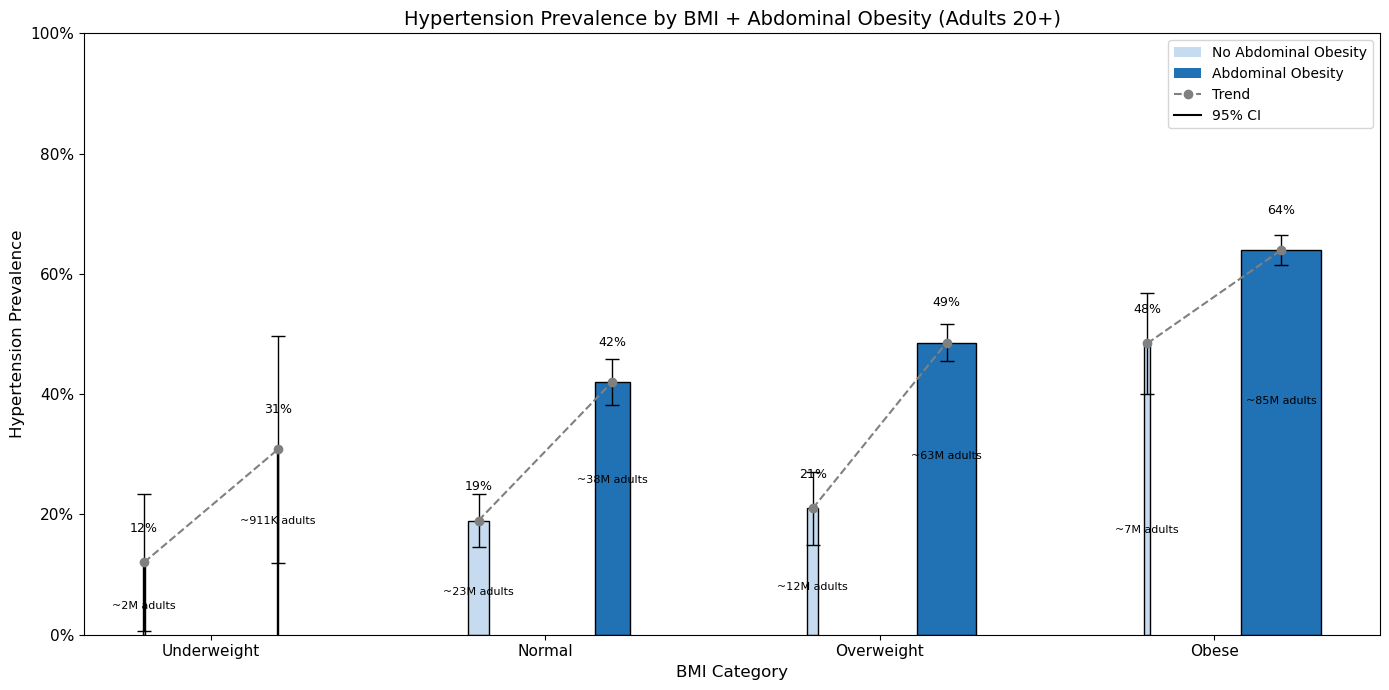

In [ ]:
# 读取处理后的数据
df = pd.read_csv("../output/hypertension_by_BMI_PLUS_abdominal_obesity_US_adults.csv")

# 分拆 BMI 和 AbOb 字段
df[['BMI_Category', 'AbOb']] = df['BMI_Ab_Group'].str.split(' \+ ', expand=True)

# 确保分类顺序一致
bmi_order = ['Underweight', 'Normal', 'Overweight', 'Obese']
abob_order = ['AbOb-', 'AbOb+']
df['BMI_Category'] = pd.Categorical(df['BMI_Category'], categories=bmi_order, ordered=True)
df['AbOb'] = pd.Categorical(df['AbOb'], categories=abob_order, ordered=True)
df = df.sort_values(['BMI_Category', 'AbOb']).reset_index(drop=True)

# 归一化人口用于柱宽度
df['Norm_Pop'] = df['Weighted_Population'] / df['Weighted_Population'].max()

# 设置颜色
color_map = {'AbOb-': '#c6dbef', 'AbOb+': '#2171b5'}

# 设置图像尺寸
plt.figure(figsize=(14, 7))

bar_positions = []
bar_heights = []
bar_colors = []
bar_widths = []

labels = []
population_labels = []
ci_lowers = []
ci_uppers = []

x_tick_positions = []
x_tick_labels = []

x = 0
group_spacing = 0.5  # 每组 BMI 类别之间的间隔

for bmi in bmi_order:
    group_df = df[df['BMI_Category'] == bmi]
    if group_df.empty:
        continue

    for _, row in group_df.iterrows():
        bar_positions.append(x)
        bar_heights.append(row['Weighted_Hypertension_Prevalence'])
        bar_colors.append(color_map[row['AbOb']])
        bar_widths.append(row['Norm_Pop'] * 0.6)  # 缩放柱宽度
        ci_lowers.append(row['Weighted_Hypertension_Prevalence'] - row['CI_Lower'])
        ci_uppers.append(row['CI_Upper'] - row['Weighted_Hypertension_Prevalence'])

        # 百分比标签
        labels.append(f"{int(round(row['Weighted_Hypertension_Prevalence'] * 100))}%")

        # 人口标签
        pop = row['Weighted_Population']
        if pop >= 1_000_000:
            population_labels.append(f"~{int(round(pop/1_000_000))}M adults")
        else:
            population_labels.append(f"~{round(pop/1_000):.0f}K adults")

        x += 1

    # 添加组的中心位置用于 x 轴标签
    x_tick_positions.append((x - 2) + 0.5)
    x_tick_labels.append(bmi)

    x += group_spacing  # 组间间隔

# 绘制柱状图
bars = plt.bar(bar_positions, bar_heights, width=bar_widths, color=bar_colors, edgecolor='black')

# 添加误差条
plt.errorbar(
    bar_positions,
    bar_heights,
    yerr=[ci_lowers, ci_uppers],
    fmt='none',
    ecolor='black',
    capsize=5,
    linewidth=1,
    label='95% CI'
)

# 添加每对组内趋势线
for i in range(0, len(bar_positions), 2):
    if i+1 < len(bar_positions):
        plt.plot(
            [bar_positions[i], bar_positions[i+1]],
            [bar_heights[i], bar_heights[i+1]],
            color='gray',
            linestyle='--',
            marker='o',
            label='Trend (within BMI group)' if i == 0 else None
        )
# 添加百分比标签和人口标签（仅向上微调百分比位置）
for i in range(len(bar_positions)):
    is_right_bar = (i % 2 == 1)

    # 百分比标签向上浮动（右柱略高）
    offset = 0.06 if is_right_bar else 0.05
    plt.text(bar_positions[i],
             bar_heights[i] + offset,
             labels[i],
             ha='center', fontsize=9)

    # 人口标签垂直居中偏下（默认逻辑）
    pop_y = (
        bar_heights[i] * 0.6 if is_right_bar else
        bar_heights[i] * 0.35
    )
    plt.text(bar_positions[i], pop_y, population_labels[i],
             ha='center', fontsize=8)


# 坐标轴与标题设置
plt.xticks(x_tick_positions, x_tick_labels, fontsize=11)
plt.yticks(fontsize=11)
plt.ylabel("Hypertension Prevalence", fontsize=12)
plt.xlabel("BMI Category", fontsize=12)
plt.ylim(0, 1)
plt.title("Hypertension Prevalence by BMI + Abdominal Obesity (Adults 20+)", fontsize=14)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# 添加图例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color_map['AbOb-'], label='No Abdominal Obesity'),
    Patch(facecolor=color_map['AbOb+'], label='Abdominal Obesity'),
    plt.Line2D([0], [0], color='gray', linestyle='--', marker='o', label='Trend'),
    plt.Line2D([0], [0], color='black', linestyle='-', label='95% CI')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()

# 保存图像
plt.savefig("../visualization/hypertension_by_BMI_plus_abob_grouped_trend_scaled.png", dpi=300)
plt.show()
